In [2]:
# Data processing 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Feature enggineering 
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay

In [3]:
data = pd.read_csv("loan_approval_data.csv")

In [4]:
# Remove unnecessary column
data = data.drop(columns =["Applicant_ID","Marital_Status","Gender"])

# Add new feature: square of DTI_Ratio and Credit_Score
data["DTI_Ratio_sq"] = data["DTI_Ratio"] ** 2
data["Credit_Score_sq"] = data["Credit_Score"] ** 2

data = data.drop(columns =["DTI_Ratio","Credit_Score"])


# EDA

In [ ]:
# Dataset Overview

data.head()
data.shape
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    950 non-null    float64
 1   Coapplicant_Income  950 non-null    float64
 2   Employment_Status   950 non-null    str    
 3   Age                 950 non-null    float64
 4   Dependents          950 non-null    float64
 5   Existing_Loans      950 non-null    float64
 6   Savings             950 non-null    float64
 7   Collateral_Value    950 non-null    float64
 8   Loan_Amount         950 non-null    float64
 9   Loan_Term           950 non-null    float64
 10  Loan_Purpose        950 non-null    str    
 11  Property_Area       950 non-null    str    
 12  Education_Level     950 non-null    str    
 13  Employer_Category   950 non-null    str    
 14  Loan_Approved       950 non-null    str    
 15  DTI_Ratio_sq        950 non-null    float64
 16  Credit_Score_sq   

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,DTI_Ratio_sq,Credit_Score_sq
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,10852.571579,5082.455789,39.971579,1.474737,1.950526,9940.452632,24802.792632,20522.825263,48.000000,0.141404,462106.437895
std,5061.632859,2943.161570,11.139797,1.105067,1.406246,5860.736885,14345.696031,11504.142575,24.245322,0.103082,96274.064284
min,2009.000000,1.000000,21.000000,0.000000,0.000000,65.000000,36.000000,1015.000000,12.000000,0.010000,302500.000000
25%,6730.750000,2472.750000,30.250000,1.000000,1.000000,4760.250000,12698.250000,9806.250000,24.000000,0.048400,379764.250000
50%,10548.000000,5205.500000,40.000000,1.000000,2.000000,9880.500000,24321.000000,21210.500000,48.000000,0.115600,459684.000000
75%,15190.000000,7620.750000,49.000000,2.000000,3.000000,15074.500000,36947.000000,30263.000000,72.000000,0.230400,543169.000000
max,19988.000000,9996.000000,59.000000,3.000000,4.000000,19996.000000,49954.000000,39995.000000,84.000000,0.360000,638401.000000


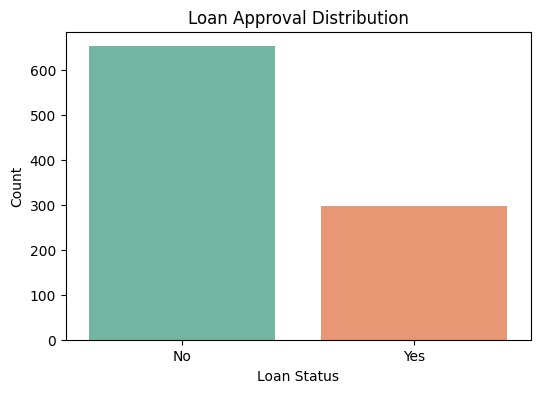

In [13]:
# Loan Status Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x="Loan_Approved",
    data=data,
    hue="Loan_Approved",
    palette='Set2',
    legend=False
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

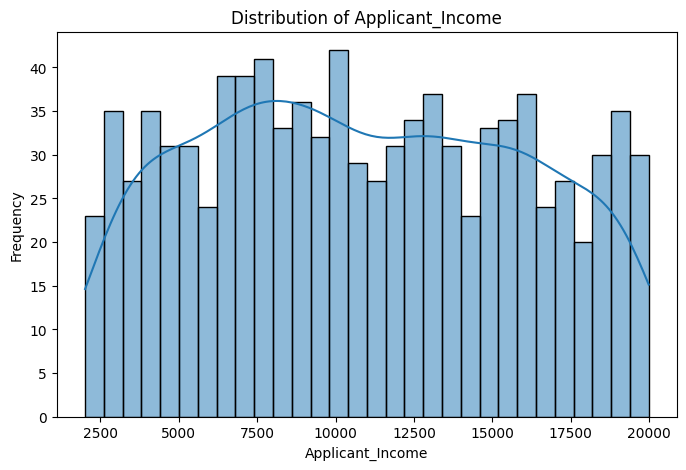

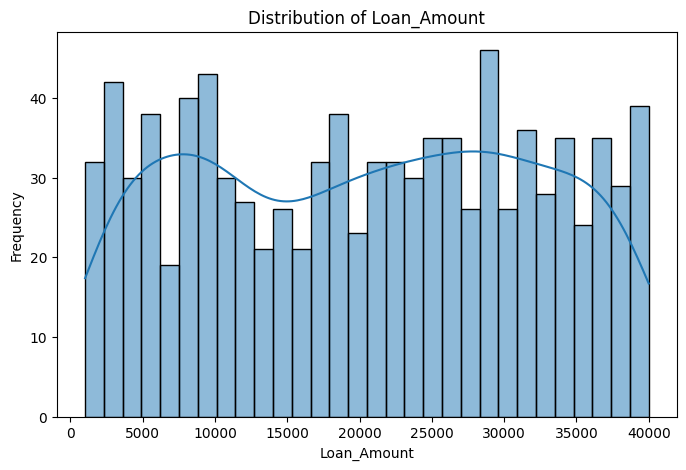

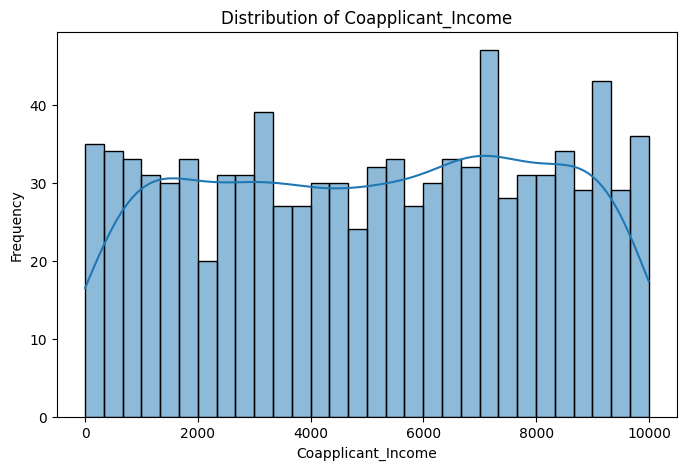

In [16]:
# Numerical Feature Analysis

numerical_features = [
    'Applicant_Income',
    'Loan_Amount',
    'Coapplicant_Income',
]

for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data[feature],
        kde=True,
        bins=30
    )

    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    plt.show()

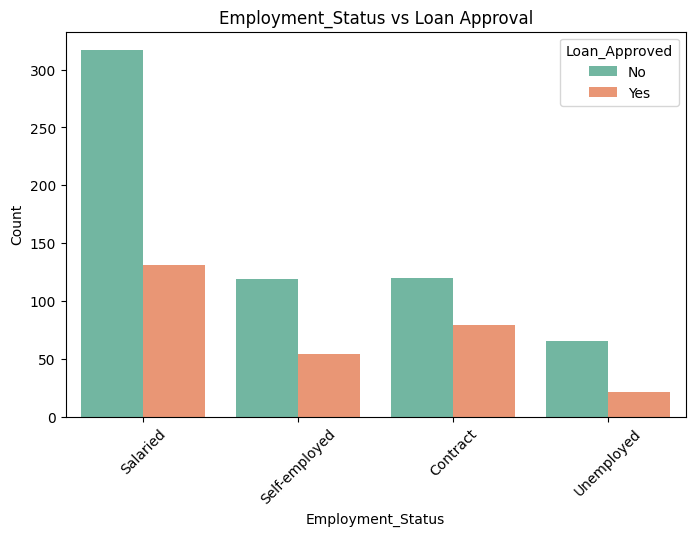

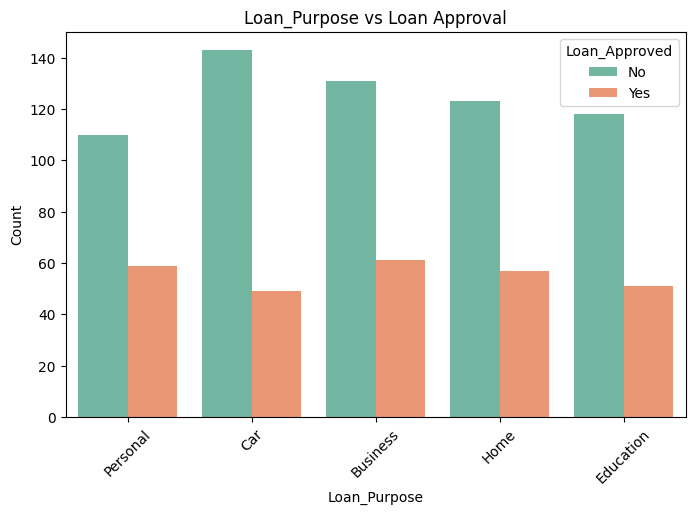

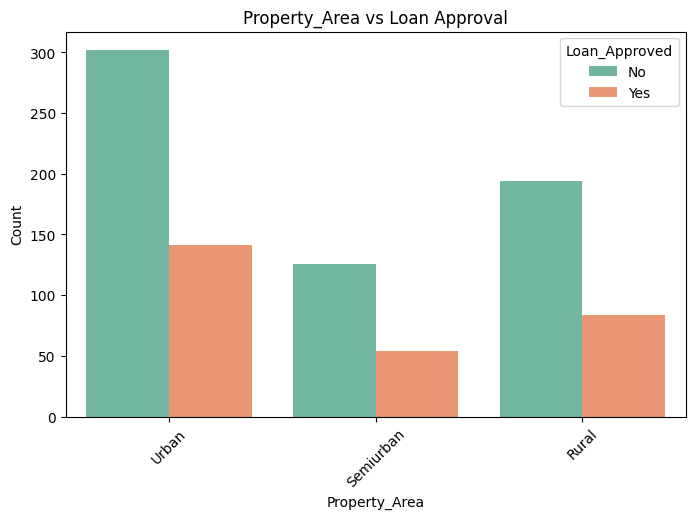

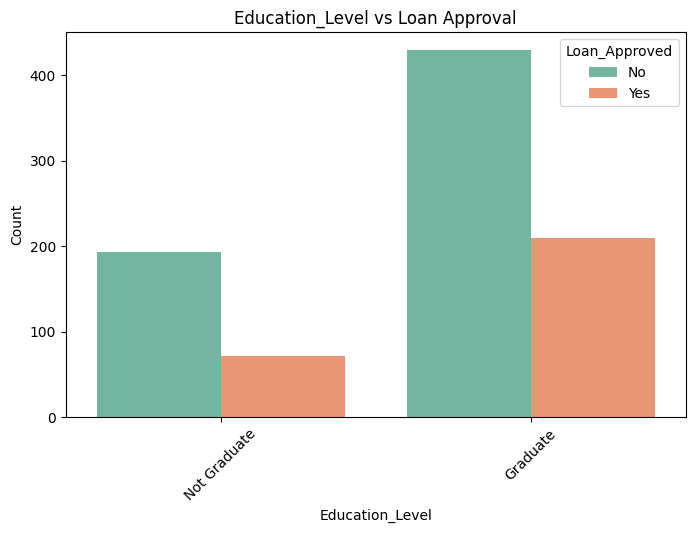

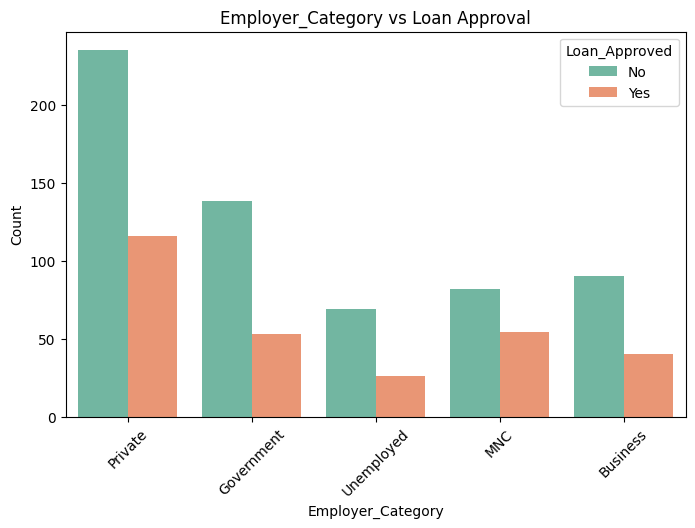

In [18]:
# Categorical Feature Analysis

categorical_features = [
    'Employment_Status',
    'Loan_Purpose',
    'Property_Area',
    'Education_Level',
    'Employer_Category'
]

for feature in categorical_features:

    plt.figure(figsize=(8,5))

    sns.countplot(
        x=feature,
        hue='Loan_Approved',
        data=data,
        palette='Set2'
    )

    plt.title(f'{feature} vs Loan Approval')
    plt.xlabel(feature)
    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.show()

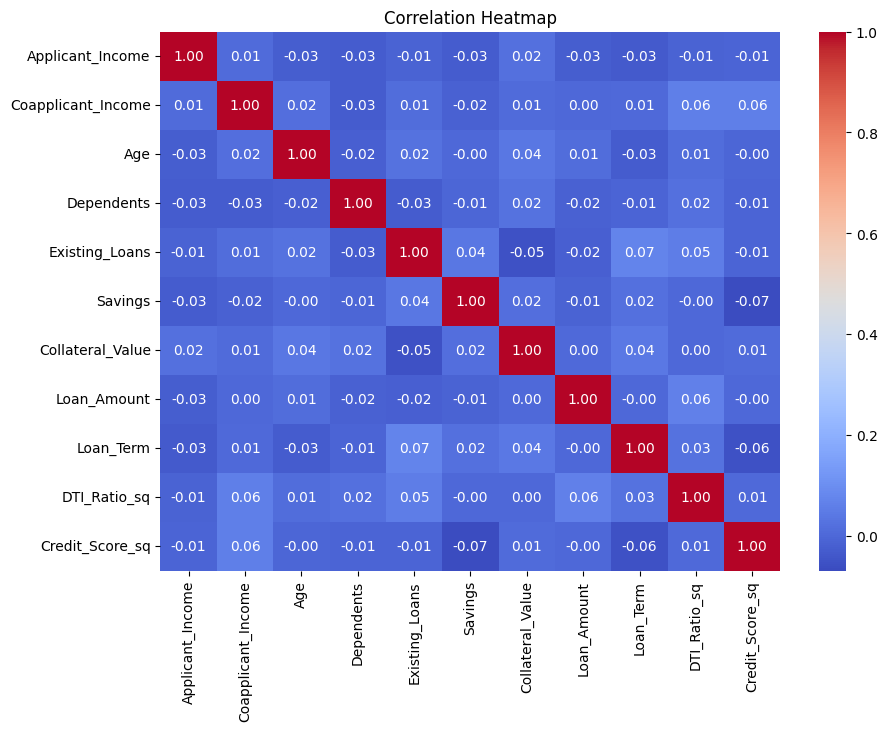

In [19]:
# Correlation Heatmap

plt.figure(figsize=(10,7))

numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

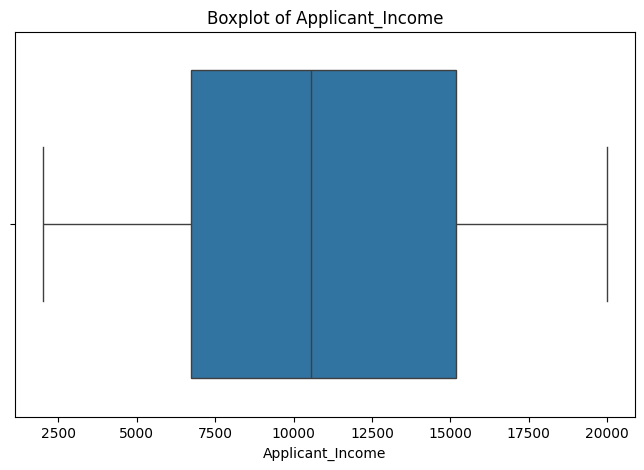

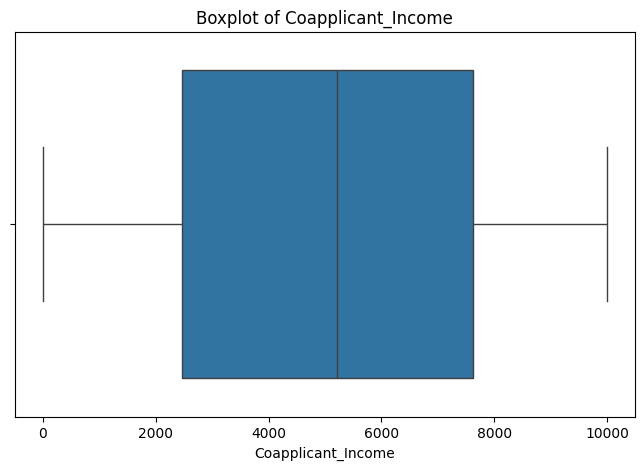

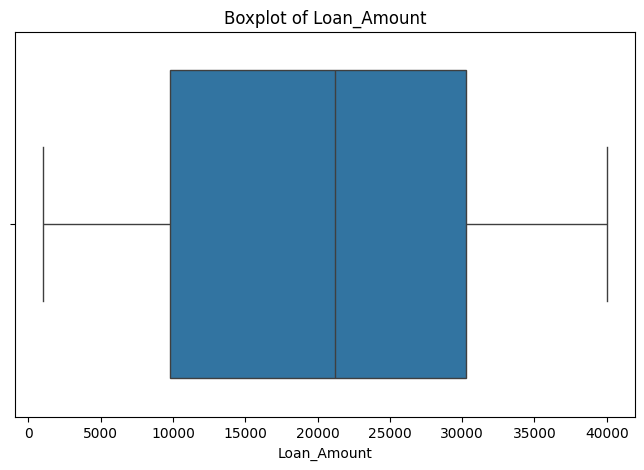

In [20]:
# Outlier Analysis

outlier_features = [
    'Applicant_Income',
    'Coapplicant_Income',
    'Loan_Amount'
]

for feature in outlier_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=data[feature]
    )

    plt.title(f'Boxplot of {feature}')

    plt.show()

# Feature Engginerring 

In [21]:
# handling missing values
data = data.dropna(subset=["Loan_Approved"])

# Encode target variable

le = LabelEncoder()
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])
y = data["Loan_Approved"]
X = data.drop(columns = ["Loan_Approved"])

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# catgeorzing features into numerical and ordinal and nominal features

numerical_cols = data.select_dtypes(include =["float64"]).columns
ordinal_cols = ["Education_Level", "Property_Area",]
nominal_cols = ["Employment_Status", "Employer_Category", "Loan_Purpose"]


In [23]:
# pipelines for numerical and ordinal and nominal features

# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler())
])

# Ordinal pipeline
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OrdinalEncoder(categories=[
    ['Not Graduate', 'Graduate'],  # Education_Level order
    ['Rural', 'Semiurban', 'Urban']  # Property_Area order
    ]))
])

# Nominal pipeline
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [24]:
# colunmn transformer to apply pipelines to respective columns

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols)
])

# Full pipeline = preprocessor + model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000,solver='lbfgs',random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state = 42))
])

In [25]:
# Define base models
estimators = [
    ('lr',lr_pipeline),
    ('rf', rf_pipeline),
    ('xgb', xgb_pipeline)
]

# Stacking Classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    passthrough=False
)

In [26]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
stacking_model.fit(X_train, y_train)

# Evaluation loop
models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'Stacking': stacking_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]  # for ROC-AUC
    
    print(f"\n{name}")
    print("Accuracy:  ", accuracy_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("Recall:    ", recall_score(y_test, y_pred))
    print("F1 Score:  ", f1_score(y_test, y_pred))
    print("ROC-AUC:   ", roc_auc_score(y_test, y_prob))



Logistic Regression
Accuracy:   0.9
Precision:  0.875
Recall:     0.8032786885245902
F1 Score:   0.8376068376068376
ROC-AUC:    0.9650527385944847

Random Forest
Accuracy:   0.9578947368421052
Precision:  0.9076923076923077
Recall:     0.9672131147540983
F1 Score:   0.9365079365079365
ROC-AUC:    0.9788410217308425

XGBoost
Accuracy:   0.9578947368421052
Precision:  0.9076923076923077
Recall:     0.9672131147540983
F1 Score:   0.9365079365079365
ROC-AUC:    0.9902147668064557

Stacking
Accuracy:   0.9578947368421052
Precision:  0.9076923076923077
Recall:     0.9672131147540983
F1 Score:   0.9365079365079365
ROC-AUC:    0.9865294192400559


In [ ]:
kfold = KFold(n_splits=5, shuffle=True ,random_state=42)

models_cv = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'Stacking': stacking_model
}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring="roc_auc")
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: 0.9228 (+/- 0.0273)


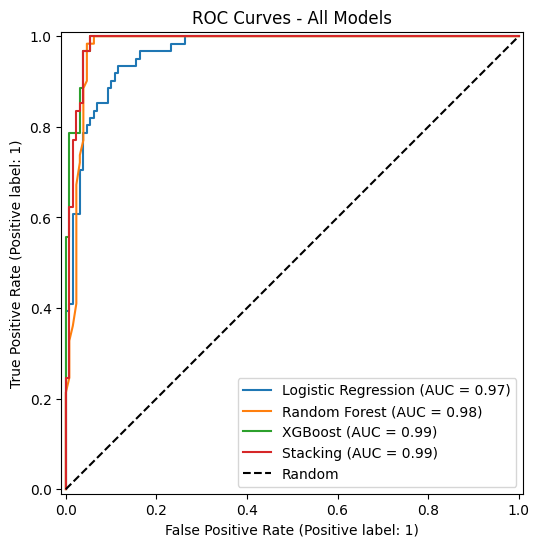

In [ ]:
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test,      # true labels
        y_prob,      # predicted probabilities
        name=name, # model name
        ax=plt.gca()
    )

plt.title("ROC Curves - All Models")
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.legend()
plt.show()


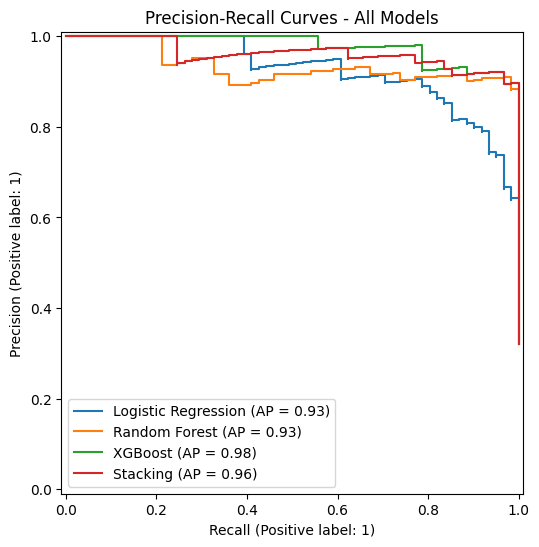

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=name,
        ax=plt.gca()
    )

plt.title("Precision-Recall Curves - All Models")
plt.legend()
plt.show()